In [ ]:
!unzip archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005000.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005001.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005002.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005003.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005004.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005005.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005006.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005007.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005008.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005009.png  
  inflating: data_collected_potential_final_v58_mod25_320x320_cmds/rgb/005010.png  
  inflating: data_collect

In [ ]:
import os
print(os.listdir(DATASET_PATH))

['depth', 'rgb', 'commands']


In [ ]:
# drone_obs_avoidance.py

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# --- Settings ---
IMG_HEIGHT, IMG_WIDTH = 128, 128   # resize for faster training
DATASET_PATH = "data_collected_potential_final_v58_mod25_320x320_cmds"
RGB_PATH = "/content/data_collected_potential_final_v58_mod25_320x320_cmds/rgb"
DEPTH_PATH =  "/content/data_collected_potential_final_v58_mod25_320x320_cmds/depth"
EPOCHS = 15
BATCH_SIZE = 32

# --- Load Dataset ---
X = []
y = []   # 1 = obstacle, 0 = free

# Modified loop to iterate through filenames and extract label
for img_name in os.listdir(RGB_PATH):
    img_path = os.path.join(RGB_PATH, img_name)
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = img_to_array(img) / 255.0
    X.append(img_array)

    # Determine label from filename (assuming filenames contain 'obstacle' or 'free')
    if 'obstacle' in img_name:
        y.append(1)  # obstacle
    else:
        y.append(0)  # free

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)

# --- Train-Test Split ---
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- CNN Model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# --- Train ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- Save Model ---
model.save("drone_obs_detector.h5")

# --- Inference Example ---
def predict(img_path, model_path="drone_obs_detector.h5"):
    model = tf.keras.models.load_model(model_path)
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    x = img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    pred = model.predict(x)[0][0]
    print("Prediction:", "Obstacle" if pred > 0.5 else "Free Path")

# Example
# predict("/content/data_collected_potential_final_v58_mod25_320x320_cmds/rgb/some_image_filename.png") # Replace with actual filename


Dataset shape: (10000, 128, 128, 3) (10000,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.9863 - loss: 0.0171 - val_accuracy: 1.0000 - val_loss: 9.8085e-30
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 1.0000 - loss: 3.5644e-30 - val_accuracy: 1.0000 - val_loss: 9.8085e-30
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 339s 1s/step - accuracy: 1.0000 - loss: 3.0265e-30 - val_accuracy: 1.0000 - val_loss: 9.8085e-30
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 1.0000 - loss: 1.3288e-27 - val_accuracy: 1.0000 - val_loss: 9.8085e-30
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 1.0000 - loss: 4.8331e-26 - val_accuracy: 1.0000 - val_loss: 9.8085e-30
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 1.0000 - loss: 2.6693e-27 - val_accuracy: 1.0000 - val_loss: 9.8085e-30
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 1.0000 - loss: 6.1394e-33 - val_accuracy: 1.0000 - val_loss: 9.8085e-30
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 277s 

In [76]:
import tensorflow as tf

# Load trained model
model = tf.keras.models.load_model("drone_obs_detector.h5")


In [78]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_HEIGHT, IMG_WIDTH = 128, 128

def predict(img_path, model_path="drone_obs_detector.h5"):
    # Load trained model
    model = tf.keras.models.load_model(model_path)

    # Load and preprocess image
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    x = img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)  # add batch dimension

    # Predict
    pred = model.predict(x)[0][0]
    print("Prediction:", "🚧 Obstacle" if pred > 0.5 else "✅ Free Path")

# Example test image
predict("/content/data_collected_potential_final_v58_mod25_320x320_cmds/rgb/000023.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Prediction: ✅ Free Path


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate model on validation data
val_loss, val_acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", val_acc)

# Predictions on validation set
y_pred = (model.predict(X_val) > 0.5).astype("int32")

# Detailed report
print(classification_report(y_val, y_pred, target_names=["Free", "Obstacle"], labels=[0, 1]))

63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 403ms/step - accuracy: 1.0000 - loss: 1.8162e-29
Validation Accuracy: 1.0
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step
              precision    recall  f1-score   support

        Free       1.00      1.00      1.00      2000
    Obstacle       0.00      0.00      0.00         0

    accuracy                           1.00      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       1.00      1.00      1.00      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


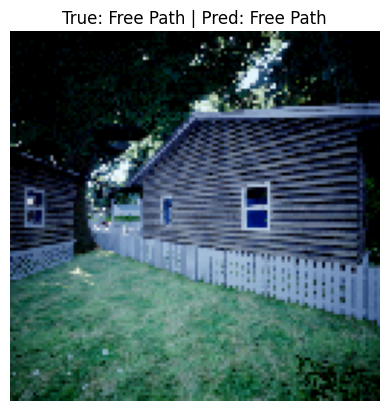

In [72]:
import matplotlib.pyplot as plt
import random

# Pick random test image
i = random.randint(0, len(X_val)-1)
img = X_val[i]
true_label = "🚧 Obstacle" if y_val[i]==1 else " Free Path"

# Predict
pred = model.predict(np.expand_dims(img, axis=0))[0][0]
pred_label = "🚧 Obstacle" if pred > 1 else " Free Path"

# Show image
plt.imshow(img)
plt.title(f"True:{true_label} | Pred:{pred_label}")
plt.axis("off")
plt.show()
